In [2]:
from scipy import optimize, interpolate
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf
import talib
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 7]

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15], dtype=float)
y = np.array([5, 7, 9, 30, 25, 28, 35, 42.81, 56.7, 70.59, 84.47, 98.36, 112.25, 126.14, 140.03])

def piecewise_linear(x, x0, y0, k1, k2):
    return np.piecewise(x, [x < x0], [lambda x: k1*x + y0-k1*x0, lambda x: k2*x + y0-k2*x0])

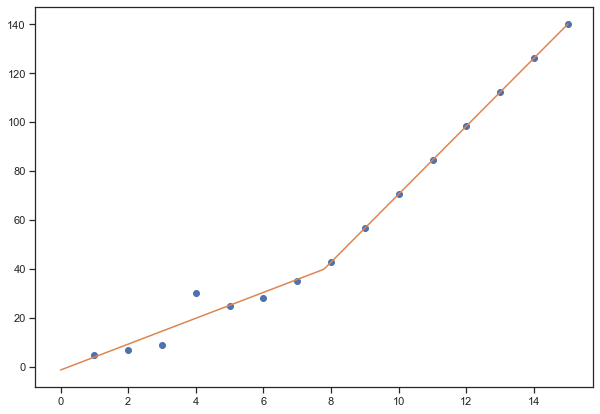

In [171]:
p, e = optimize.curve_fit(piecewise_linear, x, y)
xd = np.linspace(0, 15, 200)
plt.plot(x, y, "o")
plt.plot(xd, piecewise_linear(xd, *p))


In [172]:
def segments_fit(X, Y, count):
    xmin = X.min()
    xmax = X.max()

    seg = np.full(count - 1, (xmax - xmin) / count)

    px_init = np.r_[np.r_[xmin, seg].cumsum(), xmax]
    py_init = np.array([Y[np.abs(X - x) < (xmax - xmin) * 0.01].mean() for x in px_init])

    def func(p):
        seg = p[:count - 1]
        py = p[count - 1:]
        px = np.r_[np.r_[xmin, seg].cumsum(), xmax]
        return px, py

    def err(p):
        px, py = func(p)
        Y2 = np.interp(X, px, py)
        return np.mean((Y - Y2)**2)

    r = optimize.minimize(err, x0=np.r_[seg, py_init], method='Nelder-Mead')
    return func(r.x)

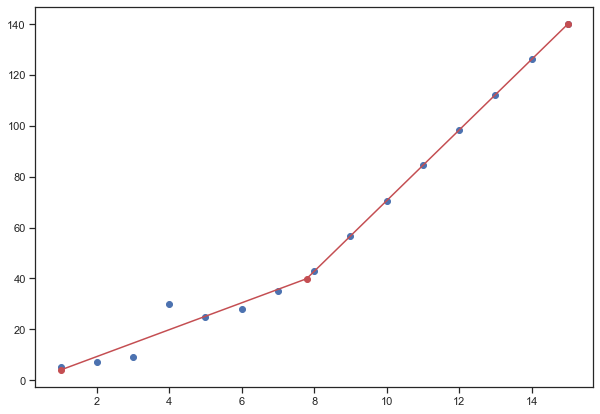

In [173]:
px, py = segments_fit(x, y, 2)

plt.plot(x, y, "o")
plt.plot(px, py, "-or");

In [174]:
df = yf.download("TSLA", start="2018-11-01", end="2020-10-18", interval="1d")
df.head()

[*********************100%***********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-10-31,66.508003,68.400002,65.820000,67.463997,67.463997,38121500
2018-11-01,67.652000,69.568001,66.945999,68.856003,68.856003,40000500
2018-11-02,68.748001,69.839996,68.181999,69.281998,69.281998,39040000
2018-11-05,68.099998,68.792000,66.028000,68.279999,68.279999,39155000
2018-11-06,67.814003,69.760002,67.218002,68.211998,68.211998,33814500


[*********************100%***********************]  1 of 1 completed


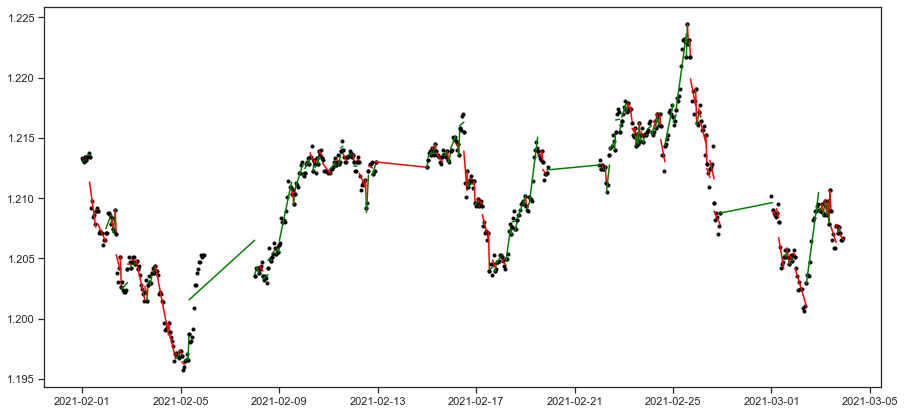

In [175]:
import pandas as pd
import pandas_datareader.data as web
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = [15, 7]

# Colecting data
market = 'EURUSD=X'
# end = dt.datetime(2021, 5, 31)
# start = dt.date(end.year-1, end.month, end.day)
# market_data = web.DataReader(market, 'yahoo', start, end)

market_data = yf.download(market, start="2021-02-01", end="2021-03-04", interval="1h")

# Calculating EMA and difference
market_data['ema'] = market_data['Close'].ewm(1).mean()
market_data['diff_pc'] = (market_data['Close'] / market_data['ema']) - 1

# Defining bull / bear signal
TH = 0
market_data['Signal'] = np.where(market_data['diff_pc'] > TH, 1, 0)
market_data['Signal'] = np.where(market_data['diff_pc'] < -TH, -1, market_data['Signal'])


# Plot data and fits

import seaborn as sns  # This is just to get nicer plots

signal = market_data['Signal']

# How many consecutive signals are needed to change trend
min_signal = 1

# Find segments bounds
bounds = (np.diff(signal) != 0) & (signal[1:] != 0)
bounds = np.concatenate(([signal[0] != 0], bounds))
bounds_idx = np.where(bounds)[0]

# Keep only significant bounds
relevant_bounds_idx = np.array([idx for idx in bounds_idx if np.all(signal[idx] == signal[idx:idx + min_signal])])

# Make sure start and end are included
if relevant_bounds_idx[0] != 0:
    relevant_bounds_idx = np.concatenate(([0], relevant_bounds_idx))
if relevant_bounds_idx[-1] != len(signal) - 1:
    relevant_bounds_idx = np.concatenate((relevant_bounds_idx, [len(signal) - 1]))

# Iterate segments
for start_idx, end_idx in zip(relevant_bounds_idx[:-1], relevant_bounds_idx[1:]):
    # Slice segment
    segment = market_data.iloc[start_idx:end_idx + 1, :]
    x = np.array(mdates.date2num(segment.index.to_pydatetime()))
    
    # Plot data
    data_color = 'grey' if signal[start_idx] > 0 else 'grey'
    plt.plot(segment.index, segment['Close'], '.', color="black")

    # Plot fit
    coef, intercept = np.polyfit(x, segment['Close'], 1)
    fit_val = coef * x + intercept
    fit_color = 'green' if coef > 0 else 'red'
    plt.plot(segment.index, fit_val, color=fit_color)

In [6]:
import plotly.graph_objects as go
import pandas as pd

md = yf.download("COPX", start="2021-06-16", end="2021-06-17", interval="2m")
md["sar_1"] = talib.SAR(md["High"], md["Low"], acceleration=0.02, maximum=0.2)
md["ht"] = talib.KAMA(md["Close"])


fig = go.Figure(
    data=go.Ohlc(x=md.index, open=md['Open'], high=md['High'], low=md['Low'], close=md['Close'])
)

fig.update_layout(
    width=950,
    height=500,
    autosize=False,
    margin=dict(t=20, b=50, l=0, r=20),
    showlegend=False,
#     shapes = [dict(x0='2021-02-09', x1='2021-02-19', y0=0, y1=1, xref='x', yref='paper', line_width=1)],
#     annotations=[dict(x='2021-02-09', y=0.05, xref='x', yref='paper', showarrow=False, xanchor='left', text='')]
)

# fig = px.line(df, facet_row="company", facet_row_spacing=0.01, height=200, width=200)
# fig.add_scatter(df["Close"])
fig.add_trace(go.Scatter(x=md.index, y=md["ht"], mode="markers", marker=dict(color="black", size=3),))

fig.update(layout_xaxis_rangeslider_visible=False)
fig.show(config={'displayModeBar': False, 'staticPlot': True})

[*********************100%***********************]  1 of 1 completed


In [177]:
from mlinsights.mlmodel import PiecewiseRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, ARDRegression
from sklearn.isotonic import IsotonicRegression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeRegressor

import numpy
import numpy.random as npr

In [178]:
X = npr.normal(size=(120, 20))
alpha = [10, -5]
t = (X[:, 0] + X[:, 6] * -3.5) > 0
switch = numpy.zeros(X.shape[0])
switch[t] = 1
y = alpha[0] * X[:, 0] * t + alpha[1] * X[:, 0] * (1 - t) + X[:, 2]

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X[:, :1], y)

# market_data

model = PiecewiseRegressor(verbose=True, binner=KBinsDiscretizer(n_bins=5))
model.fit(X_train, y_train)

PiecewiseRegressor(
    binner=DecisionTreeRegressor(
        criterion='mse',
        max_depth=None,
        max_features=None,
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        min_impurity_split=None,
        min_samples_leaf=150,
        min_samples_split=2,
        min_weight_fraction_leaf=0.0,
        random_state=None,
        splitter='best'
    ),
    estimator=LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False),
    n_jobs=None, verbose=False)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:    0.0s finished


PiecewiseRegressor(binner=DecisionTreeRegressor(min_samples_leaf=150),
                   estimator=LinearRegression())

[*********************100%***********************]  1 of 1 completed


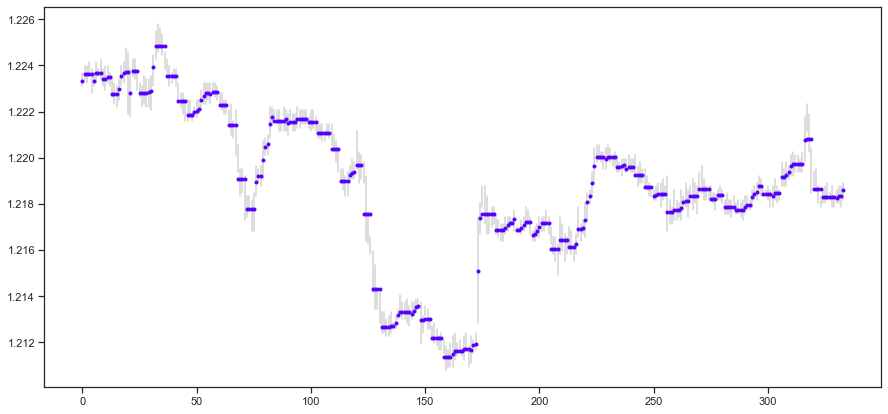

In [180]:
## lin_x = np.array([[x / 100] for x in range(-300, 300)])

# market_data = yf.download(market, start="2021-05-09", end="2021-05-29", interval="1h")
market_data = yf.download(market, start="2021-06-01", end="2021-06-10", interval="30m")


df = market_data

plt.rcParams['figure.figsize'] = [15, 7]
fig, ax = plt.subplots(1, 1)

# OHLC
cnt = 0
for dt, row in df.iterrows():
    ax.plot([cnt, cnt], [row["Low"], row["High"]], color="lightgrey")
#     color = "black"
#     if row["Open"] < row["Close"]:
#         color = "green"
#     if row["Open"] > row["Close"]:
#         color = "red"
#     ax.plot([cnt, cnt], [row["Open"], row["Close"]], color=color)
    cnt += 1
    

XX = []
YY = []

cnt = 0
for dt, row in market_data.iterrows():
#     YY.append(row["Low"])
    YY.append((row["Open"] + row["Close"] + row["Low"] + row["High"]) / 4)
    XX.append([cnt])
    cnt += 1
    
XX = np.array(XX)
YY = np.array(YY)

# N = 100
# print(">>>", int(len(YY)/(N+3)))

model = PiecewiseRegressor(
    binner=DecisionTreeRegressor(
        criterion='mse',  # mean squared error
        min_samples_leaf=2,
        min_weight_fraction_leaf=0.01,
        splitter='best'
    ),
    estimator=IsotonicRegression()
)
model3 = PiecewiseRegressor(
    binner=DecisionTreeRegressor(
        criterion='mse',
        min_samples_leaf=5,
        min_weight_fraction_leaf=0.0,
        splitter='best'
    ),
    estimator=LinearRegression()
)

model.fit(XX, YY)

model2 = PiecewiseRegressor(binner=KBinsDiscretizer(n_bins=20), estimator=LinearRegression())
model2.fit(XX, YY)


YY2 = []
for v in model.predict(XX):
    YY2.append(v)
YY2 = np.array(YY2)

model3.fit(XX, YY2)
# print(XX2)

# ax.plot(XX, YY, ".", label='data', color="#ccc")
ax.plot(XX[:, 0], model.predict(XX), ".", label="DecisionTree", color="#50f")
# ax.plot(XX[:, 0], model3.predict(XX), ".", label="DecisionTree-2", color="#f50")
# ax.plot(XX[:, 0], model2.predict(XX), ".", label="KBinsDiscretizer", color="#d0d")
# ax.set_title("Piecewise Linear Regression")
# None

[*********************100%***********************]  1 of 1 completed


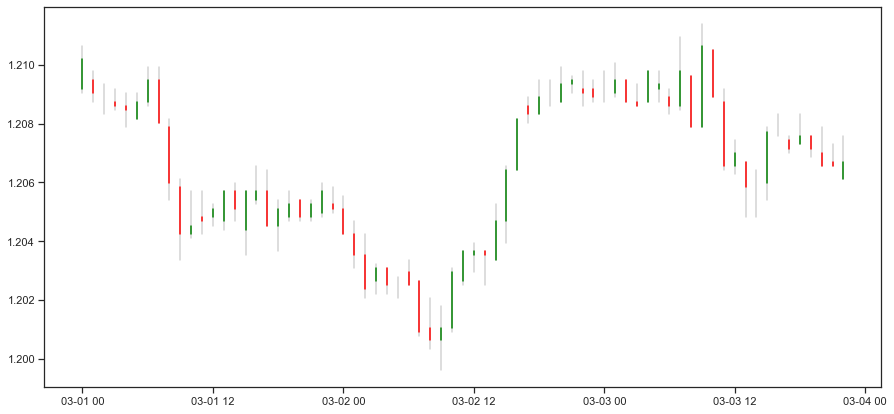

In [181]:
from scipy.signal import argrelmin, argrelmax

df = yf.download(market, start="2021-03-01", end="2021-03-04", interval="1h")

# OHLC shadows
for dt, row in df.iterrows():
    plt.plot([dt, dt], [row["Low"], row["High"]], color="lightgrey")

# OHLC bodies
for dt, row in df.iterrows():
    color = "black"
    if row["Open"] < row["Close"]:
        color = "green"
    if row["Open"] > row["Close"]:
        color = "red"
    plt.plot([dt, dt], [row["Open"], row["Close"]], color=color)


# df = market_data # load your stock prices in OHLC format
# h = df['Close'].dropna().copy() # make a series of Highs
# l = df['Close'].dropna().copy()  # make a series of Lows

# N = 3 # number of iterations

# for i in range(N):
#     h = h.iloc[argrelmax(h.values)[0]] # locate maxima in Highs
#     l = l.iloc[argrelmin(l.values)[0]] # locate minima in Lows
#     h = h[~h.index.isin(l.index)] # drop index that appear in both
#     l = l[~l.index.isin(h.index)] # drop index that appear in both
    
# # h.iloc[argrelmax(h.values)[0]]

# plt.plot(market_data.index, market_data['Close'], ',', color="black")
# plt.plot(h.index, h, color="red")
# plt.plot(l.index, l, color="blue")

In [182]:
df = yf.download("SPY", start="2021-01-01", end="2021-03-30", interval="1h")

[*********************100%***********************]  1 of 1 completed


<Figure size 1080x576 with 0 Axes>

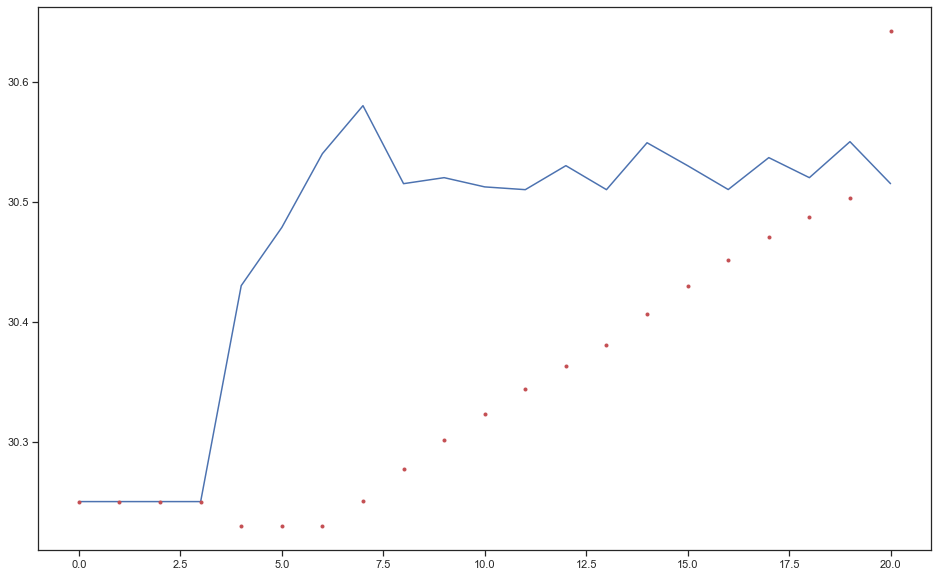

In [183]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn
%matplotlib inline
plt.rcParams['figure.figsize'] = [16, 10]

seaborn.set(style='ticks')
plt.figure(figsize=(15,8))

close = [30.25, 30.25, 30.25, 30.25, 30.43, 30.4785, 30.54, 30.58, 30.515, 30.52, 30.5123, 30.51, 30.53, 30.51, 30.5491, 30.53, 30.5101, 30.5367, 30.52, 30.55, 30.515, 30.515, 30.51, 30.51, 30.515, 30.515, 30.515, 30.51, 30.515, 30.55, 30.55, 30.5497, 30.535, 30.55, 30.51, 30.52, 30.55, 30.51, 30.54, 30.54, 30.5, 30.45, 30.47, 30.4468, 30.4699, 30.4493, 30.4468, 30.41, 30.46, 30.46, 30.44, 30.46, 30.44, 30.45, 30.46, 30.4239, 30.4, 30.4299, 30.365, 30.4299, 30.3999, 30.34, 30.4, 30.399, 30.3999, 30.3623, 30.3799, 30.36, 30.34, 30.315, 30.315, 30.33, 30.3599, 30.335, 30.35, 30.35, 30.36, 30.35, 30.3599, 30.345, 30.345, 30.35, 30.355, 30.35, 30.36, 30.355, 30.35, 30.35, 30.35, 30.32, 30.3234, 30.33, 30.33, 30.32, 30.32, 30.31, 30.31, 30.303, 30.31, 30.31, 30.31, 30.32, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.31, 30.3029, 30.31, 30.31, 30.32, 30.32, 30.32, 30.3101, 30.32, 30.32, 30.315, 30.3158, 30.32, 30.32, 30.325, 30.31, 30.31, 30.31, 30.305, 30.32, 30.3, 30.305, 30.3017, 30.31, 30.3047, 30.3099, 30.3005, 30.3058, 30.3, 30.31, 30.31, 30.3002, 30.305, 30.31, 30.305, 30.3055, 30.3058, 30.3, 30.3, 30.31, 30.305, 30.3001, 30.309, 30.305, 30.31, 30.3, 30.3023, 30.303, 30.305, 30.3, 30.29, 30.29, 30.29, 30.29, 30.29, 30.29, 30.29, 30.29, 30.3, 30.2915, 30.295, 30.3, 30.31, 30.3, 30.3, 30.2984, 30.2701, 30.3, 30.3, 30.29, 30.29, 30.29, 30.29, 30.6, 30.68, 30.43, 30.42, 30.4, 30.3193, 30.295, 30.29, 30.1501, 30.2, 30.2, 30.15, 30.15, 30.15, 30.16, 30.16, 30.152, 30.16, 30.13, 30.0401, 29.92, 30.0, 30.0, 30.0, 29.9779, 29.95, 29.93, 30.02, 29.98, 29.9887, 30.005, 30.02, 30.0481, 29.995, 29.9995, 29.88, 29.88, 29.94, 29.95, 29.955, 29.94, 29.9457, 29.955, 29.99, 29.99, 29.99, 29.991, 29.99, 30.06, 30.0, 30.01, 30.0589, 30.025, 30.1, 30.15, 30.1075, 30.17, 30.16, 30.135, 30.12, 30.12, 30.13, 30.1591, 30.252, 30.21, 30.171, 30.24, 30.21, 30.24, 30.3, 30.29, 30.3, 30.298, 30.3, 30.29, 30.285, 30.27, 30.225, 30.2174, 30.32, 30.245, 30.245, 30.2597, 30.2339, 30.3, 30.2294, 30.275, 30.275, 30.3, 30.3, 30.298, 30.275, 30.29, 30.29, 30.24, 30.17, 30.235, 30.2001, 30.245, 30.235, 30.26, 30.245, 30.26, 30.22, 30.2, 30.2, 30.1701, 30.17, 30.056, 30.0554, 30.0081, 30.065, 30.0488, 30.0662, 30.0307, 30.0773, 30.09, 30.0616, 30.065, 30.09, 30.065, 30.08, 30.0999, 30.06, 30.07, 30.08, 30.08, 30.1, 30.085, 30.1, 30.0701, 30.1, 30.0702, 30.08, 30.1, 30.085, 30.0749, 30.09, 30.095, 30.09, 30.085, 30.08, 30.0701, 30.0701, 30.07, 30.03, 30.08, 30.0582, 30.08, 30.0562, 30.0201, 30.08, 30.05, 30.05, 30.4916, 30.4699, 30.47, 30.4735, 30.4701, 30.485, 30.44, 30.4, 30.44, 30.44, 30.44, 30.438, 30.44, 30.44, 30.45, 30.4401, 30.4529, 30.46, 30.44, 30.44, 30.4505, 30.46, 30.455, 30.45, 30.42, 30.42, 30.42, 30.4, 30.43, 30.43, 30.43, 30.435, 30.43, 30.41, 30.43, 30.43, 30.438, 30.4201, 30.4201, 30.45, 30.4311, 30.445, 30.455, 30.445, 30.47, 30.445, 30.445, 30.4611, 30.465, 30.4621, 30.4693, 30.47, 30.47, 30.465, 30.4701, 30.47, 30.47, 30.47, 30.46, 30.44, 30.44, 30.44, 30.425, 30.39, 30.395, 30.3801, 30.34, 30.36, 30.36, 30.37, 30.4, 30.32, 30.4082]
sar = [30.25, 30.25, 30.25, 30.25, 30.23, 30.23, 30.23, 30.2504, 30.276768, 30.30102656, 30.3233444352, 30.343876880384, 30.36276672995328, 30.380145391557015, 30.406320852401315, 30.429878767161185, 30.451080890445066, 30.47016280140056, 30.487336521260502, 30.502792869134453, 30.6419, 30.639262, 30.63667676, 30.6341432248, 30.631660360304, 30.62922715309792, 30.62684261003596, 30.62450575783524, 30.622215642678537, 30.619971329824967, 30.61777190322847, 30.6156164651639, 30.613504135860623, 30.611434053143412, 30.609405372080545, 30.607417264638933, 30.605468919346155, 30.603559540959232, 30.601688350140048, 30.599854583137247, 30.598057491474503, 30.59413519181552, 30.58368708030659, 30.573865855488194, 30.564633904158903, 30.55595586990937, 30.547798517714806, 30.540130606651918, 30.529720158119765, 30.520142545470183, 30.511331141832567, 30.50322465048596, 30.495766678447083, 30.488905344171318, 30.482592916637614, 30.476785483306607, 30.471442644642078, 30.4699, 30.46291, 30.4511608, 30.440821504, 30.43172292352, 30.418881714227197, 30.407838274235388, 30.4, 30.3999, 30.3999, 30.391513999999997, 30.384302039999998, 30.378099754399997, 30.365603793695996, 30.355107186704636, 30.3, 30.301198, 30.302372039999998, 30.303522599199997, 30.304650147215998, 30.30686414132736, 30.308989575674264, 30.311029992647292, 30.3129887929414, 30.314869241223743, 30.316674471574792, 30.3184074927118, 30.320071193003326, 30.321668345283193, 30.323201611471866, 30.324673547012992, 30.326086605132474, 30.36, 30.359199999999998, 30.358416, 30.35764768, 30.3568947264, 30.356156831872, 30.35543369523456, 30.353616347425177, 30.350399366579666, 30.347375404584884, 30.344532880309792, 30.341860907491206, 30.339349253041735, 30.336988297859232, 30.334768999987677, 30.332682859988417, 30.33072188838911, 30.328878575085763, 30.327145860580618, 30.325517108945782, 30.323986082409036, 30.322546917464493, 30.321194102416623, 30.319922456271627, 30.3, 30.300398, 30.30078804, 30.3011702792, 30.301544873616002, 30.301911976143682, 30.30227173662081, 30.302980867155977, 30.303661632469737, 30.304315167170948, 30.30494256048411, 30.305544858064746, 30.306123063742156, 30.30667814119247, 30.307211015544773, 30.307722574922984, 30.309059220427606, 30.33, 30.3296, 30.329207999999998, 30.328303679999998, 30.3269054592, 30.325591131648, 30.32354384111616, 30.321660333826866, 30.319927507120717, 30.31833330655106, 30.316866642026977, 30.31551731066482, 30.314275925811636, 30.313133851746706, 30.31208314360697, 30.311116492118412, 30.310227172748938, 30.31, 30.3, 30.3002, 30.300396, 30.30058808, 30.31, 30.3098, 30.3, 30.3, 30.31, 30.309801999999998, 30.3001, 30.300298, 30.31, 30.31, 30.3, 30.3002, 30.31, 30.3098, 30.309008, 30.308247679999997, 30.307517772799997, 30.306817061887998, 30.306144379412476, 30.30549860423598, 30.30487866006654, 30.304283513663876, 30.303712173117322, 30.30316368619263, 30.302637138744924, 30.29, 30.290399999999998, 30.290792, 30.29117616, 30.31, 30.309199999999997, 30.308415999999998, 30.30764768, 30.3068947264, 30.306156831872, 30.30543369523456, 30.27, 30.2766, 30.292735999999998, 30.308226559999998, 30.3230974976, 30.68, 30.672786, 30.65767456, 30.6356140864, 30.596772959488, 30.56103912272896, 30.528163992910642, 30.49034759361958, 30.45631283425762, 30.425681550831857, 30.391591764732034, 30.36159275296419, 30.3284417675492, 30.299931920092313, 30.275413451279388, 30.237763299074686, 30.18056590524124, 30.126452724192994, 30.083162179354396, 30.048529743483517, 30.020823794786814, 29.9059, 29.9059, 29.910463999999997, 29.918728159999997, 29.926496470399996, 29.933798682175997, 29.940662761245438, 29.94711499557071, 29.95318009583647, 30.0482, 30.044836, 30.04153928, 30.0383084944, 30.035142324511998, 30.03203947802176, 30.02899868846132, 30.026018714692096, 30.023098340398253, 30.020236373590286, 30.01743164611848, 30.014683013196112, 30.01198935293219, 29.88, 29.883599999999998, 29.887127999999997, 29.890585439999995, 29.893973731199996, 29.897294256575996, 29.90540248631296, 29.92067833713418, 29.93503763690613, 29.95383462595364, 29.97112785587735, 29.98703762740716, 30.00167461721459, 30.015140647837423, 30.02752939601043, 30.038927044329593, 30.060234339896635, 30.079410905906972, 30.096669815316275, 30.112202833784647, 30.12618255040618, 30.13876429536556, 30.158112579921696, 30.17513907033109, 30.19012238189136, 30.203307696064396, 30.21491077253667, 30.225121479832268, 30.234106902252396, 30.3, 30.3, 30.2174, 30.2174, 30.219452, 30.22146296, 30.32, 30.317764, 30.31557272, 30.3134252656, 30.311320760287998, 30.309258345082238, 30.307237178180593, 30.305256434616982, 30.30331530592464, 30.30141299980615, 30.299548739810028, 30.297721765013826, 30.29593132971355, 30.290894076525007, 30.286058313464007, 30.28141598092545, 30.276959341688432, 30.272680968020893, 30.26857372930006, 30.264630780128055, 30.260845548922934, 30.26, 30.256400000000003, 30.252944000000003, 30.24962624, 30.246441190400002, 30.235014718976004, 30.217981541457924, 30.19699338731213, 30.178104048580916, 30.161103643722825, 30.14580327935054, 30.13203295141549, 30.11963965627394, 30.108485690646546, 30.09844712158189, 30.0081, 30.009738, 30.01134324, 30.0129163752, 30.016395720192, 30.01973589138432, 30.02294245572895, 30.02602075749979, 30.0289759271998, 30.03323737156781, 30.037243129273744, 30.041008541517318, 30.044548029026277, 30.0478751472847, 30.051002638447617, 30.05394248014076, 30.056705931332313, 30.059303575452375, 30.061745360925233, 30.06404063926972, 30.066198200913536, 30.068226308858723, 30.0701327303272, 30.1, 30.099402, 30.09881596, 30.0976633216, 30.093603522304, 30.08978731096576, 30.086200072307815, 30.082828067969345, 30.08, 30.0201, 30.0201, 30.08, 30.0201, 30.0201, 30.029529999999998, 30.038771399999998, 30.047827971999997, 30.056703412559997, 30.065401344308796, 30.07392531742262, 30.08227881107417, 30.090465234852687, 30.09848793015563, 30.106350171552517, 30.114055168121467, 30.12160606475904, 30.12900594346386, 30.136257824594583, 30.14336466810269, 30.150329374740636, 30.157154787245823, 30.163843691500904, 30.170398817670886, 30.176822841317467, 30.183118384491117, 30.189288016801296, 30.19533425646527, 30.201259571335964, 30.207066379909243, 30.21275705231106, 30.218333911264835, 30.22379923303954, 30.22915524837875, 30.234404143411176, 30.23954806054295, 30.244589099332092, 30.249529317345452, 30.25437073099854, 30.25911531637857, 30.263765010051, 30.268321709849978, 30.272787275652977, 30.277163530139916, 30.28145225953712, 30.285655214346377, 30.28977411005945, 30.29381062785826, 30.297766415301094, 30.30164308699507, 30.30544222525517, 30.309165380750066, 30.312814073135065, 30.316389791672364, 30.319893995838918, 30.323328115922138, 30.326693553603693, 30.32999168253162, 30.333223848880987, 30.336391371903368, 30.3394955444653, 30.342537633575994, 30.345518880904475, 30.348440503286387, 30.351303693220657, 30.354109619356244, 30.35685942696912, 30.359554238429737, 30.4916, 30.488767999999997, 30.482817279999995, 30.477104588799996, 30.471620405247997, 30.466355589038077, 30.461301365476555, 30.45282328354796]

close, sar = close[:21], sar[:21]

close, sar

fig, ax = plt.subplots()
ax.plot(close)
ax.plot(sar, "r.")
# ax.grid(True, which='both')
# seaborn.despine(ax=ax, offset=0) # the important part here